# Data Preprocessing

In [2]:
import pandas as pd
import numpy as np

In [3]:
# load data
df = pd.read_csv('../data-preparation-new/github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])

In [4]:
df.head(5)

,name,full_name,stars,forks,watchers,open_issues,size,has_wiki,has_projects,has_downloads,...,has_homepage,topic_count,has_discussions,is_template,allow_forking,visibility,subscribers_count,contributors_count,commits_count,readme_size
0,freeCodeCamp,freeCodeCamp/freeCodeCamp,418037,40103,418037,291,498427,0,1,1,...,1,16,0,0,1,public,8566,5937,38323,32109
1,build-your-own-x,codecrafters-io/build-your-own-x,380134,35400,380134,380,1061,0,0,1,...,1,6,0,0,1,public,6019,128,573,45203
2,awesome,sindresorhus/awesome,360860,29113,360860,44,1495,0,0,1,...,0,5,0,0,1,public,7844,656,1168,80444
3,free-programming-books,EbookFoundation/free-programming-books,357451,63369,357451,76,19455,0,0,1,...,1,5,0,0,1,public,9835,3288,9521,15689
4,public-apis,public-apis/public-apis,341482,35995,341482,461,5030,0,0,1,...,1,13,0,0,1,public,4294,1379,4535,192180


In [5]:
# Features of the dataset
print(df.columns)
# Number of Features
len(df.columns)

Index(['name', 'full_name', 'stars', 'forks', 'watchers', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 'is_fork',
       'archived', 'language', 'license', 'created_at', 'updated_at',
       'pushed_at', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility',
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size'],
      dtype='object')


28

In [6]:
# Parse and normalize time-related features
date = pd.to_datetime("2025-5-17")
df["project_age"] = (date.date() - df["created_at"].dt.date).apply(lambda x: x.days)
df["days_since_update"] = (date.date() - df["updated_at"].dt.date).apply(lambda x: x.days)
df["days_since_push"] = (date.date() - df["pushed_at"].dt.date).apply(lambda x: x.days)


# Handle missing values
df["license"] = df["license"].fillna("None")
df["language"] = df["language"].fillna("Unknown")

# Derived rate-based features
df["forks_per_day"] = df["forks"] / (df["project_age"] + 1)
df["issues_per_day"] = df["open_issues"] / (df["project_age"] + 1)
df["update_rate"] = 1 / (1 + df["days_since_update"])

# Replace inf with NaN and drop rows with NaN
# df.replace([np.inf, -np.inf], np.nan, inplace=True)
# df.dropna(inplace=True)

In [7]:
print(df[['stars', 'forks']].corr())

          stars     forks
stars  1.000000  0.632439
forks  0.632439  1.000000


In [8]:
# Update of dataframe
df.head()

,name,full_name,stars,forks,watchers,open_issues,size,has_wiki,has_projects,has_downloads,...,subscribers_count,contributors_count,commits_count,readme_size,project_age,days_since_update,days_since_push,forks_per_day,issues_per_day,update_rate
0,freeCodeCamp,freeCodeCamp/freeCodeCamp,418037,40103,418037,291,498427,0,1,1,...,8566,5937,38323,32109,3797,0,0,10.558978,0.076619,1.0
1,build-your-own-x,codecrafters-io/build-your-own-x,380134,35400,380134,380,1061,0,0,1,...,6019,128,573,45203,2565,0,36,13.795791,0.148090,1.0
2,awesome,sindresorhus/awesome,360860,29113,360860,44,1495,0,0,1,...,7844,656,1168,80444,3963,0,2,7.344349,0.011100,1.0
3,free-programming-books,EbookFoundation/free-programming-books,357451,63369,357451,76,19455,0,0,1,...,9835,3288,9521,15689,4236,0,15,14.956101,0.017937,1.0
4,public-apis,public-apis/public-apis,341482,35995,341482,461,5030,0,0,1,...,4294,1379,4535,192180,3345,0,198,10.757621,0.137776,1.0


In [9]:
df.columns

Index(['name', 'full_name', 'stars', 'forks', 'watchers', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 'is_fork',
       'archived', 'language', 'license', 'created_at', 'updated_at',
       'pushed_at', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility',
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size', 'project_age', 'days_since_update', 'days_since_push',
       'forks_per_day', 'issues_per_day', 'update_rate'],
      dtype='object')

In [10]:
A = [
            'stars', 'forks', 'watchers', 'open_issues',
            'size', 'topic_count', 'subscribers_count', 
            'contributors_count', 'commits_count', 'readme_size',
            'project_age', 'days_since_update', 'days_since_push',
            'forks_per_day', 'issues_per_day', 'update_rate','has_wiki', 'has_projects', 'has_downloads', 'is_fork',
            'archived', 'language', 'license', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility'
        ]
for i in df.columns:
    if i not in A:
        print(i)

name
full_name
created_at
updated_at
pushed_at


In [15]:
!pip install catboost ngboost xgboost lightgbm

# Optional packages (install as needed)
!pip install h2o tpot auto-sklearn prophet pygam interpret  # For specialized models

# If you wanst rule-based models
!pip install rulefit

  Obtaining dependency information for catboost from https://files.pythonhosted.org/packages/4c/71/a05501a74e043b2c3ea5264dce8f5d55f0c84c91900581c93a947f258d64/catboost-1.2.8-cp310-cp310-win_amd64.whl.metadata
  Obtaining dependency information for ngboost from https://files.pythonhosted.org/packages/6a/51/9a9d247492c076500d24bdfc8b29c8b76f4e710f7b1f89d35d24f752299d/ngboost-0.5.5-py3-none-any.whl.metadata
  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for plotly from https://files.pythonhosted.org/packages/ee/11/83ae52318353f9da4a88cc23e7f9dbc3d449b3f0fd6158fba15eb3c3b816/plotly-6.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for lifelines>=0.25 from https://files.pythonhosted.org/packages/14/f7/379e185a75ac8166ac70756d0ba68d9a2b02b555c7fde4983246752396bd/lifelines-0.30.0-py3


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#'

[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached rulefit-0.3.1.tar.gz (25 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for rulefit: filename=rulefit-0.3.1-py3-none-any.whl size=7805 sha256=ec42cd9d219f1fb13cb744c733410a2eb3e125125b1020d7b73cbf1cd4d99146
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\0d\e7\77\17919d2e417a6589ae77e0722a78f2287c308fca24af14c600
Successfully built rulefit



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
!pip install --upgrade xgboost
!pip install --upgrade scikit-learn

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/47/78/27daa8e0287ce205908f089564472af42eb4646146a51d2fbb76ef8f3880/xgboost-3.0.1-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 9.4 MB/s eta 0:00:16
   ---------------------------------------- 1.0/150.0 MB 9.5 MB/s eta 0:00:16
   ---------------------------------------- 1.1/150.0 MB 10.4 MB/s eta 0:00:15
   ---------------------------------------- 1.8/150.0 MB 9.7 MB/s eta 0:00:16
    --------------------------------------- 2.8/150.0 MB 9.5 MB/s eta 0:00:16
    --------------------------------------- 3.4/150.0 MB 10.0 MB/s eta 0:00:15
   - -------------------------------------- 4.3/150.0 MB 9.5 MB/s eta 0:00:16
   - -------------------------------------- 5.0/150.0 MB 9.9 MB/s eta 0:00:15
   - -------------------------------------- 5.4/150.0 MB 9.6 MB/s eta 0:00:16
   - ---------------

ERROR: Exception:
Traceback (most recent call last):
  File "D:\python\pythonProject5\.venv\lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
  File "D:\python\pythonProject5\.venv\lib\site-packages\pip\_internal\cli\req_command.py", line 248, in wrapper
    return func(self, options, args)
  File "D:\python\pythonProject5\.venv\lib\site-packages\pip\_internal\commands\install.py", line 377, in run
    requirement_set = resolver.resolve(
  File "D:\python\pythonProject5\.venv\lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 161, in resolve
    self.factory.preparer.prepare_linked_requirements_more(reqs)
  File "D:\python\pythonProject5\.venv\lib\site-packages\pip\_internal\operations\prepare.py", line 565, in prepare_linked_requirements_more
    self._complete_partial_requirements(
  File "D:\python\pythonProject5\.venv\lib\site-packages\pip\_internal\operations\prepare.py", line 479, in _complete


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
!python.exe -m pip install --upgrade pip

  Obtaining dependency information for pip from https://files.pythonhosted.org/packages/29/a2/d40fb2460e883eca5199c62cfc2463fd261f760556ae6290f88488c362c0/pip-25.1.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.8 MB 7.2 MB/s eta 0:00:01
   -------------------- ------------------- 0.9/1.8 MB 9.9 MB/s eta 0:00:01
   ------------------------------- -------- 1.5/1.8 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------  1.8/1.8 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 8.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.2.1
    Uninstalling pip-23.2.1:
      Successfully uninstalled pip-23.2.1


# Pipeline

In [27]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                             AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.svm import SVR, NuSVR, LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


from sklearn.linear_model import (HuberRegressor, QuantileRegressor, 
                                BayesianRidge, ARDRegression, 
                                PassiveAggressiveRegressor, TheilSenRegressor,
                                OrthogonalMatchingPursuit, RANSACRegressor)
from sklearn.ensemble import (HistGradientBoostingRegressor, 
                            StackingRegressor, VotingRegressor)
from sklearn.neighbors import RadiusNeighborsRegressor
from catboost import CatBoostRegressor
from ngboost import NGBRegressor  # For probabilistic forecasting



import joblib
import os


class GitHubRepoPreprocessor:
    """Custom preprocessing pipeline for GitHub repository metadata."""
    
    def __init__(self, reference_date=None):
        self.date = reference_date or datetime(2025, 5, 17)
        self.features = [
            'forks', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 
       'archived', 'language', 'license', 
       'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size', 'project_age', 'days_since_push',
       'forks_per_day', 'issues_per_day'
        ] # delete 'watchers', 'is_fork', 'allow_forking', 'visibility', 'days_since_update' and 'update_rate'
        self.numeric_features = [
            'forks', 'open_issues',
            'size', 'topic_count', 'subscribers_count', 
            'contributors_count', 'commits_count', 'readme_size',
            'project_age', 'days_since_push',
            'forks_per_day', 'issues_per_day'
        ]
        self.categorical_features = ["language", "license"]
        self.column_transformer = None

    def transform(self, df):
        # Parse and normalize time-related features
        df["project_age"] = (self.date.date() - df["created_at"].dt.date).apply(lambda x: x.days)
        df["days_since_update"] = (self.date.date() - df["updated_at"].dt.date).apply(lambda x: x.days)
        df["days_since_push"] = (self.date.date() - df["pushed_at"].dt.date).apply(lambda x: x.days)

        # Handle missing values
        df["license"] = df["license"].fillna("None")
        df["language"] = df["language"].fillna("Unknown")

        # Derived rate-based features
        df["forks_per_day"] = df["forks"] / (df["project_age"] + 1)
        df["issues_per_day"] = df["open_issues"] / (df["project_age"] + 1)
        df["update_rate"] = 1 / (1 + df["days_since_update"])

        return df[self.features], df["stars"]

    def get_preprocessor(self):
        """Construct and return a fitted ColumnTransformer"""
        self.column_transformer = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), self.numeric_features),
                ("cat", OneHotEncoder(handle_unknown="ignore"), self.categorical_features)
            ]
        )
        return self.column_transformer


def train_and_evaluate_models(df, save_path="best_model_cv.pkl"):
    """Train multiple regressors and save the best performing one."""
    preprocessor = GitHubRepoPreprocessor()
    X, y = preprocessor.transform(df)
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Preprocessing pipeline
    processor = preprocessor.get_preprocessor()

    # Candidate models
    models = {
        # Linear Models
        'Linear Regression': LinearRegression(),
        'Ridge (α=0.1)': Ridge(alpha=0.1),
        'Ridge (α=0.5)': Ridge(alpha=0.5),
        'Ridge (α=1.0)': Ridge(alpha=1.0),
        'Ridge (α=5.0)': Ridge(alpha=5.0),
        'Lasso (α=0.001)': Lasso(alpha=0.001),
        'Lasso (α=0.01)': Lasso(alpha=0.01),
        'Lasso (α=0.1)': Lasso(alpha=0.1),
        'ElasticNet (α=0.001)': ElasticNet(alpha=0.001, l1_ratio=0.5),
        'ElasticNet (α=0.01)': ElasticNet(alpha=0.01, l1_ratio=0.3),
        'ElasticNet (α=0.1)': ElasticNet(alpha=0.1, l1_ratio=0.7),
        'Huber Regressor (ϵ=1.35)': HuberRegressor(epsilon=1.35),
        'Huber Regressor (ϵ=2.0)': HuberRegressor(epsilon=2.0),
        'Quantile Regressor (α=0.5)': QuantileRegressor(quantile=0.5),
        'Quantile Regressor (α=0.9)': QuantileRegressor(quantile=0.9),
        'Bayesian Ridge': BayesianRidge(),
        'ARD Regression': ARDRegression(),
        'Passive Aggressive Regressor': PassiveAggressiveRegressor(random_state=42),
        'Theil-Sen Regressor': TheilSenRegressor(random_state=42),
        'Orthogonal Matching Pursuit': OrthogonalMatchingPursuit(),
        'RANSAC Regressor': RANSACRegressor(random_state=42),
        
        # Tree-based Models
        'Decision Tree (max_depth=3)': DecisionTreeRegressor(max_depth=3, random_state=42),
        'Decision Tree (max_depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
        'Decision Tree (max_depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
        'Decision Tree (max_depth=None)': DecisionTreeRegressor(max_depth=None, random_state=42),
        'Decision Tree (min_samples_leaf=5)': DecisionTreeRegressor(min_samples_leaf=5, random_state=42),
        'Decision Tree (min_samples_split=10)': DecisionTreeRegressor(min_samples_split=10, random_state=42),
        'Decision Tree (max_features=sqrt)': DecisionTreeRegressor(max_features='sqrt', random_state=42),
        'Decision Tree (max_features=log2)': DecisionTreeRegressor(max_features='log2', random_state=42),
        
        # Ensemble Methods
        'Random Forest (n=50)': RandomForestRegressor(n_estimators=50, random_state=42),
        'Random Forest (n=100)': RandomForestRegressor(n_estimators=100, random_state=42),
        'Random Forest (n=200)': RandomForestRegressor(n_estimators=200, random_state=42),
        'Random Forest (n=300)': RandomForestRegressor(n_estimators=300, random_state=42),
        'Random Forest (max_depth=5)': RandomForestRegressor(max_depth=5, random_state=42),
        'Random Forest (max_depth=10)': RandomForestRegressor(max_depth=10, random_state=42),
        'Random Forest (max_features=sqrt)': RandomForestRegressor(max_features='sqrt', random_state=42),
        'Random Forest (max_features=log2)': RandomForestRegressor(max_features='log2', random_state=42),
        'Random Forest (min_samples_leaf=5)': RandomForestRegressor(min_samples_leaf=5, random_state=42),
        'Random Forest (bootstrap=False)': RandomForestRegressor(bootstrap=False, random_state=42),
        
        
        # Gradient Boosting
        'Gradient Boosting (n=50)': GradientBoostingRegressor(n_estimators=50, random_state=42),
        'Gradient Boosting (n=100)': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting (n=200)': GradientBoostingRegressor(n_estimators=200, random_state=42),
        'Gradient Boosting (learning_rate=0.01)': GradientBoostingRegressor(learning_rate=0.01, random_state=42),
        'Gradient Boosting (learning_rate=0.1)': GradientBoostingRegressor(learning_rate=0.1, random_state=42),
        'Gradient Boosting (max_depth=3)': GradientBoostingRegressor(max_depth=3, random_state=42),
        'Gradient Boosting (max_depth=5)': GradientBoostingRegressor(max_depth=5, random_state=42),
        'Gradient Boosting (max_depth=7)': GradientBoostingRegressor(max_depth=7, random_state=42),
        'Gradient Boosting (max_depth=9)': GradientBoostingRegressor(max_depth=9, random_state=42),
        'Gradient Boosting (subsample=0.5)': GradientBoostingRegressor(subsample=0.5, random_state=42),
        'Gradient Boosting (max_features=sqrt)': GradientBoostingRegressor(max_features='sqrt', random_state=42),
        'Gradient Boosting (loss=absolute)': GradientBoostingRegressor(loss='absolute_error', random_state=42),
        'Gradient Boosting (loss=huber)': GradientBoostingRegressor(loss='huber', random_state=42),
        
        #AdaBoost
        'AdaBoost (DT base)': AdaBoostRegressor(random_state=42),
        'AdaBoost (n=50)': AdaBoostRegressor(n_estimators=50, random_state=42),
        'AdaBoost (n=100)': AdaBoostRegressor(n_estimators=100, random_state=42),
        'AdaBoost (n=200)': AdaBoostRegressor(n_estimators=200, random_state=42),
        'AdaBoost (learning_rate=0.5)': AdaBoostRegressor(learning_rate=0.5, random_state=42),
        'AdaBoost (learning_rate=1.0)': AdaBoostRegressor(learning_rate=1.0, random_state=42),
        
        
        #Extra Tree
        'Extra Trees (n=50)': ExtraTreesRegressor(n_estimators=50, random_state=42),
        'Extra Trees (n=100)': ExtraTreesRegressor(n_estimators=100, random_state=42),
        'Extra Trees (n=200)': ExtraTreesRegressor(n_estimators=200, random_state=42),
        'Extra Trees (n=250)': ExtraTreesRegressor(n_estimators=250, random_state=42),
        'Extra Trees (n=300)': ExtraTreesRegressor(n_estimators=300, random_state=42),
        'Extra Trees (max_depth=5)': ExtraTreesRegressor(max_depth=5, random_state=42),
        'Extra Trees (max_depth=10)': ExtraTreesRegressor(max_depth=10, random_state=42),
        'Extra Trees (max_features=sqrt)': ExtraTreesRegressor(max_features='sqrt', random_state=42),
        'Extra Trees (max_features=log2)': ExtraTreesRegressor(max_features='log2', random_state=42),
        'Extra Trees (bootstrap=True)': ExtraTreesRegressor(bootstrap=True, random_state=42),
        
        
        #Bagging
        'Bagging (DT base)': BaggingRegressor(random_state=42),
        'Bagging (n=50)': BaggingRegressor(n_estimators=50, random_state=42),
        'Bagging (n=100)': BaggingRegressor(n_estimators=100, random_state=42),
        'Bagging (n=200)': BaggingRegressor(n_estimators=200, random_state=42),
        'Bagging (max_samples=0.5)': BaggingRegressor(max_samples=0.5, random_state=42),
        'Bagging (max_features=0.5)': BaggingRegressor(max_features=0.5, random_state=42),
        'Bagging (bootstrap=False)': BaggingRegressor(bootstrap=False, random_state=42),
        
        
        # SVM
        'SVR (linear)': SVR(kernel='linear'),
        'SVR (rbf)': SVR(kernel='rbf'),
        'SVR (poly)': SVR(kernel='poly'),
        'SVR (sigmoid)': SVR(kernel='sigmoid'),
        'SVR (C=0.1)': SVR(C=0.1),
        'SVR (C=1.0)': SVR(C=1.0),
        'SVR (C=10)': SVR(C=10),
        'SVR (epsilon=0.1)': SVR(epsilon=0.1),
        'SVR (epsilon=0.5)': SVR(epsilon=0.5),
        'NuSVR (nu=0.1)': NuSVR(nu=0.1),
        'NuSVR (nu=0.5)': NuSVR(nu=0.5),
        'LinearSVR (epsilon=0.0)': LinearSVR(epsilon=0.0, random_state=42),
        'LinearSVR (epsilon=1.0)': LinearSVR(epsilon=1.0, random_state=42),
        
        # Neighbors
        'KNN (k=3)': KNeighborsRegressor(n_neighbors=3),
        'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
        'KNN (k=10)': KNeighborsRegressor(n_neighbors=10),
        'KNN (k=20)': KNeighborsRegressor(n_neighbors=20),
        'KNN (weights=uniform)': KNeighborsRegressor(weights='uniform'),
        'KNN (weights=distance)': KNeighborsRegressor(weights='distance'),
        'KNN (p=1)': KNeighborsRegressor(p=1),  # Manhattan distance
        'KNN (p=2)': KNeighborsRegressor(p=2),  # Euclidean distance
        
        # Neural Networks
        'MLP (1 layer)': MLPRegressor(hidden_layer_sizes=(128,), max_iter=1000, random_state=42),
        'MLP (2 layers)': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42),
        'MLP (3 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=42),
        'MLP (4 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32, 16), max_iter=1000, random_state=42),
        'MLP (adam)': MLPRegressor(solver='adam', random_state=42),
        'MLP (lbfgs)': MLPRegressor(solver='lbfgs', random_state=42),
        'MLP (sgd)': MLPRegressor(solver='sgd', random_state=42),
        'MLP (relu)': MLPRegressor(activation='relu', random_state=42),
        'MLP (tanh)': MLPRegressor(activation='tanh', random_state=42),
        'MLP (logistic)': MLPRegressor(activation='logistic', random_state=42),
        'MLP (alpha=0.0001)': MLPRegressor(alpha=0.0001, random_state=42),
        'MLP (alpha=0.001)': MLPRegressor(alpha=0.001, random_state=42),
        'MLP (batch_size=32)': MLPRegressor(batch_size=32, random_state=42),
        'MLP (batch_size=64)': MLPRegressor(batch_size=64, random_state=42),
        
        
        # Advanced Gradient Boosting (LightGBM)
        'LightGBM (n=100)': LGBMRegressor(n_estimators=100, random_state=42),
        'LightGBM (n=200)': LGBMRegressor(n_estimators=200, random_state=42),
        'LightGBM (max_depth=3)': LGBMRegressor(max_depth=3, random_state=42),
        'LightGBM (max_depth=6)': LGBMRegressor(max_depth=6, random_state=42),
        'LightGBM (learning_rate=0.001)': LGBMRegressor(learning_rate=0.001, random_state=42),
        'LightGBM (learning_rate=0.01)': LGBMRegressor(learning_rate=0.01, random_state=42),
        'LightGBM (learning_rate=0.05)': LGBMRegressor(learning_rate=0.05, random_state=42),
        'LightGBM (learning_rate=0.1)': LGBMRegressor(learning_rate=0.1, random_state=42),
        'LightGBM (num_leaves=31)': LGBMRegressor(num_leaves=31, random_state=42),
        'LightGBM (num_leaves=63)': LGBMRegressor(num_leaves=63, random_state=42),
        'LightGBM (subsample=0.5)': LGBMRegressor(subsample=0.5, random_state=42),
        'LightGBM (colsample_bytree=0.5)': LGBMRegressor(colsample_bytree=0.5, random_state=42),
        'LightGBM (reg_alpha=0)': LGBMRegressor(reg_alpha=0, random_state=42),
        'LightGBM (reg_alpha=1)': LGBMRegressor(reg_alpha=1, random_state=42),
        'LightGBM (reg_lambda=0)': LGBMRegressor(reg_lambda=0, random_state=42),
        'LightGBM (reg_lambda=1)': LGBMRegressor(reg_lambda=1, random_state=42),
        'LightGBM (boosting_type=gbdt)': LGBMRegressor(boosting_type='gbdt', random_state=42),
        'LightGBM (boosting_type=dart)': LGBMRegressor(boosting_type='dart', random_state=42),
        'LightGBM (boosting_type=goss)': LGBMRegressor(boosting_type='goss', random_state=42),
        'LightGBM (objective=regression)': LGBMRegressor(objective='regression', random_state=42),
        'LightGBM (objective=mae)': LGBMRegressor(objective='mae', random_state=42),
        
        # Advanced Gradient Boosting (CatBOOST)
        'CatBoost (n=100)': CatBoostRegressor(iterations=100, random_state=42, verbose=0),
        'CatBoost (n=200)': CatBoostRegressor(iterations=200, random_state=42, verbose=0),
        'CatBoost (depth=3)': CatBoostRegressor(depth=3, random_state=42, verbose=0),
        'CatBoost (depth=6)': CatBoostRegressor(depth=6, random_state=42, verbose=0),
        'CatBoost (learning_rate=0.001)': CatBoostRegressor(learning_rate=0.001, random_state=42, verbose=0),
        'CatBoost (learning_rate=0.01)': CatBoostRegressor(learning_rate=0.01, random_state=42, verbose=0),
        'CatBoost (learning_rate=0.05)': CatBoostRegressor(learning_rate=0.05, random_state=42, verbose=0),
        'CatBoost (learning_rate=0.1)': CatBoostRegressor(learning_rate=0.1, random_state=42, verbose=0),
        'CatBoost (l2_leaf_reg=1)': CatBoostRegressor(l2_leaf_reg=1, random_state=42, verbose=0),
        'CatBoost (l2_leaf_reg=3)': CatBoostRegressor(l2_leaf_reg=3, random_state=42, verbose=0),
        'CatBoost (border_count=32)': CatBoostRegressor(border_count=32, random_state=42, verbose=0),
        'CatBoost (border_count=128)': CatBoostRegressor(border_count=128, random_state=42, verbose=0),
        'CatBoost (grow_policy=SymmetricTree)': CatBoostRegressor(grow_policy='SymmetricTree', random_state=42, verbose=0),
        'CatBoost (grow_policy=Lossguide)': CatBoostRegressor(grow_policy='Lossguide', random_state=42, verbose=0),
        'CatBoost (loss_function=RMSE)': CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
        'CatBoost (loss_function=MAE)': CatBoostRegressor(loss_function='MAE', random_state=42, verbose=0),
        'CatBoost (one_hot_max_size=2)': CatBoostRegressor(one_hot_max_size=2, random_state=42, verbose=0),
        'CatBoost (one_hot_max_size=10)': CatBoostRegressor(one_hot_max_size=10, random_state=42, verbose=0),
        
    }

    results = []
    best_model = None
    best_score = -np.inf


    for name, model in models.items():
        try:
            pipeline = Pipeline([
                ("preprocessor", processor),
                ("regressor", model)
            ])

            
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)

            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)

            # Store results
            model_params = str(model.get_params())
            results.append({
                'Model': name,
                'Parameters': model_params,
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            })

            # Save the best model
            if r2 > best_score:
                best_score = r2
                best_model = Pipeline([
                ("preprocessor", processor),
                ("regressor", model)
            ])
                
            print(f"{name: <30} | R2: {r2:.4f} | RMSE: {rmse:.2f}")
            # print(f"{name: <30} | R2: {r2:.4f} | RMSE: {rmse:.2f} | {best_model: <30} ({best_score: <30})")
            
        except Exception as e:
            print(f"Error with {name}: {str(e)}")
            continue

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='R2', ascending=False)

    # Display all results
    print("\n=== All Model Results ===")
    print(results_df.to_string())

    if best_model:
        joblib.dump(best_model, save_path)
        #print(f"\n Best model {best_model: <30} ({best_score: <30})")
        print(f"\n Best model saved to: {os.path.abspath(save_path)}")
    
    return results_df

In [28]:
# load data
df = pd.read_csv('../data-preparation-new/github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
results_df = train_and_evaluate_models(df, save_path="best_model.pkl")

Linear Regression              | R2: 0.4668 | RMSE: 20824.71
Ridge (α=0.1)                  | R2: 0.4701 | RMSE: 20758.80
Ridge (α=0.5)                  | R2: 0.4789 | RMSE: 20586.08
Ridge (α=1.0)                  | R2: 0.4849 | RMSE: 20468.32
Ridge (α=5.0)                  | R2: 0.5026 | RMSE: 20112.82


D:\python\pythonProject5\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 32761001724.379547, tolerance: 151429513.52133387
  model = cd_fast.sparse_enet_coordinate_descent(


Lasso (α=0.001)                | R2: 0.4658 | RMSE: 20843.10


D:\python\pythonProject5\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13254937999.967194, tolerance: 151429513.52133387
  model = cd_fast.sparse_enet_coordinate_descent(


Lasso (α=0.01)                 | R2: 0.4659 | RMSE: 20842.31


...

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
LightGBM (boosting_type=goss)  | R2: 0.5848 | RMSE: 18376.95
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000300 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2709
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 27
[LightGBM] [Info] Start training from score 52325.408750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

D:\python\pythonProject5\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

D:\python\pythonProject5\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM (objective=mae)       | R2: 0.6919 | RMSE: 15829.86
CatBoost (n=100)               | R2: 0.6214 | RMSE: 17547.46
CatBoost (n=200)               | R2: 0.6502 | RMSE: 16865.70
CatBoost (depth=3)             | R2: 0.6418 | RMSE: 17067.13
CatBoost (depth=6)             | R2: 0.6679 | RMSE: 16433.39
CatBoost (learning_rate=0.001) | R2: 0.4597 | RMSE: 20963.30
CatBoost (learning_rate=0.01)  | R2: 0.6750 | RMSE: 16258.25
CatBoost (learning_rate=0.05)  | R2: 0.6674 | RMSE: 16448.03
CatBoost (learning_rate=0.1)   | R2: 0.6230 | RMSE: 17511.07
CatBoost (l2_leaf_reg=1)       | R2: 0.6789 | RMSE: 16160.71
CatBoost (l2_leaf_reg=3)       | R2: 0.6699 | RMSE: 16386.11
CatBoost (border_count=32)     | R2: 0.6509 | RMSE: 16849.37
CatBoost (border_count=128)    | R2: 0.6473 | RMSE: 16936.37
CatBoost (grow_policy=SymmetricTree) | R2: 0.6679 | RMSE: 16433.39
CatBoost (grow_policy=Lossguide) | R2: 0.6574 | RMSE: 16693.15
CatBoost (loss_function=RMSE)  | R2: 0.6679 | RMSE: 16433.39
CatBoost (loss_f

In [39]:
import matplotlib.pyplot as plt
import pandas as pd  # Make sure you import pandas if you haven't already

def visualize_results(results_df):
    plt.figure(figsize=(12, 8))

    # Sort by R2 score in descending order
    results_df = results_df.sort_values(by='R2', ascending=False)

    # Select the top 10 models
    top_20_df = results_df.head(20)

    # Plot the top 20
    bars = plt.barh(top_20_df['Model'], top_20_df['R2'], color='skyblue')

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2,
                 f'{width:.3f}',
                 va='center', ha='left', fontsize=9)

    # Customize plot
    plt.xlabel('R2 Score', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.title('Top 20 Model Performance Comparison (R2 Score)', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save and show
    plt.savefig('top_20_model_comparison.png', dpi=500, bbox_inches='tight')
    plt.show()

In [40]:
#Number of experments have been done
len(results_df)

144

In [41]:
#results_df.to_csv("results.csv", sep='\t')

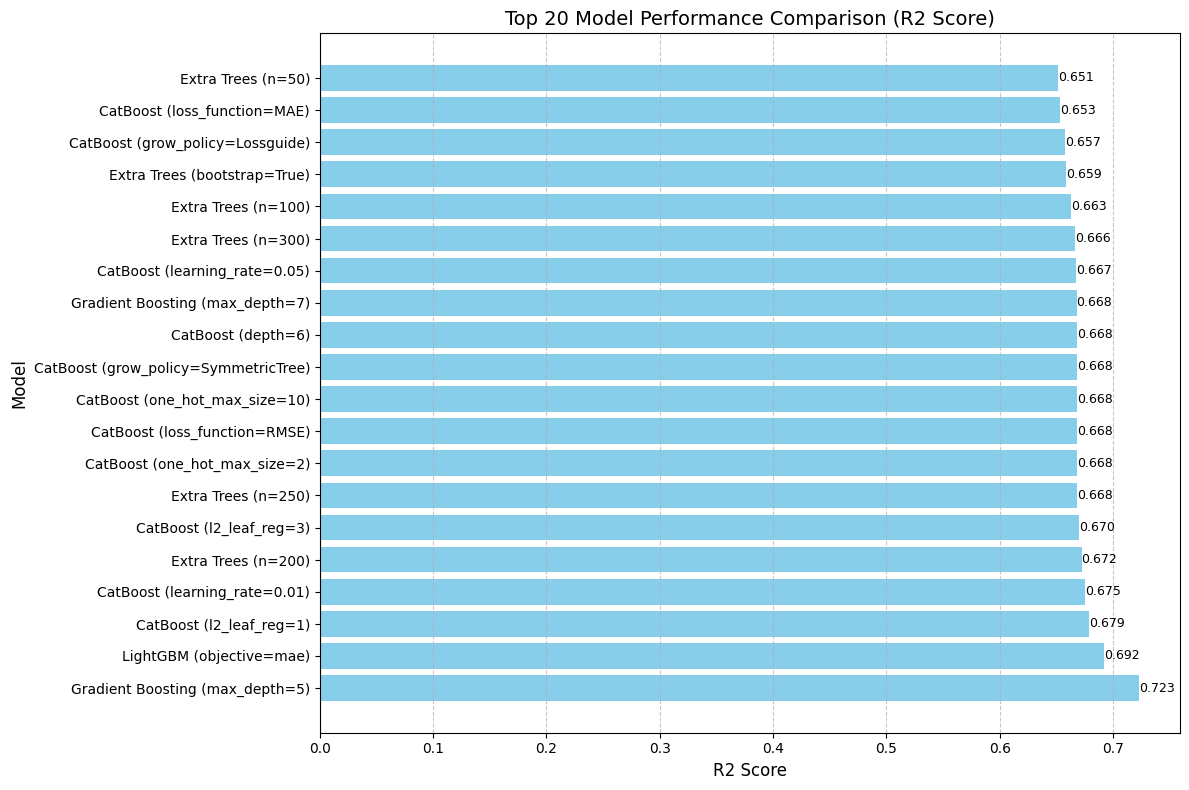

In [42]:
# Call the visualization function
visualize_results(results_df)